### Constructing simple plots

Construction of plots generally follows the article from the baseline study. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from actors import Survey
from plots import * # fontsizes

In [2]:
from dataframe_gymnastics import (
    map_institution,
    year_2019,
    year_2026,
    load_2019_data_students,
    load_2019_data_educators,
    load_2019_data_admintech,
    load_2026_data_students_filter_with_2019,
    load_2026_data_educators_filter_with_2019, 
    load_2026_data_admintech_filter_with_2019,
    merge_2019_with_2026
)


df_2019_students, common_questions_students_2019 = load_2019_data_students()
df_2019_educators, common_questions_educators_2019 = load_2019_data_educators()
df_2019_admintech, common_questions_2019_admintech = load_2019_data_admintech()
df_2026_students = load_2026_data_students_filter_with_2019(common_questions_students_2019)
df_2026_educators = load_2026_data_educators_filter_with_2019(common_questions_educators_2019)
df_2026_admintech = load_2026_data_admintech_filter_with_2019(common_questions_2019_admintech)
(
    df_students, 
    df_educators, 
    df_admintech, 
    common_questions_students, 
    common_questions_educators, 
    common_questions_admintech
) = merge_2019_with_2026(
        df_2019_students, 
        df_2019_educators, 
        df_2019_admintech, 
        df_2026_students, 
        df_2026_educators, 
        df_2026_admintech
    )

c:\Users\NoahH\OneDrive - UiT Office 365\Personal OneDrive copy\Tromsø\BaseGeo_2_0\BaseGeo_2_0_data_analysis\dataframe_gymnastics.py:72: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["institution"] = df["Which of these educational institutions are you studying at?"].replace(
c:\Users\NoahH\OneDrive - UiT Office 365\Personal OneDrive copy\Tromsø\BaseGeo_2_0\BaseGeo_2_0_data_analysis\dataframe_gymnastics.py:124: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["institution"] = df["Where are you employed?"].replace(
c:\Users\NoahH

In [3]:

import matplotlib


def make_shared_histogram(questions_to_plot, survey, title, hide=True, concatenate_counts_with=None):
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Determine the number of groups and options
    num_questions = len(questions_to_plot)
    
    # Define bar widths and spacing
    total_width = 0.8  # Total space allocated for all bars at one X-position
    bar_width = total_width / num_questions
    
    # Color palette or list of colors to differentiate the questions
    # colors = plt.cm.get_cmap('tab10', num_questions) 
    # colors = plt.cm.get_cmap('autumn', num_questions) 
    colors = matplotlib.colormaps["tab20"]

    # Loop through each question and plot its bars with an offset
    for i, question_text in enumerate(questions_to_plot):
        question = survey.search(question_text)
        if isinstance(question, int):
            print(f"{question_text = } not found in survey")
            continue  # Skip if counts are empty or None

        counts = question.get_counts()  # Assuming this returns a list/array of values
        if concatenate_counts_with is not None:
            # Find the question to concatenate with
            concat_question = concatenate_counts_with.search(question_text)
            if isinstance(concat_question, int):
                print(f"Concatenation question '{concatenate_counts_with}' not found for '{question_text}'.")
                continue  # Skip if concatenation question is not found

            # Concatenate counts
            counts = question.get_counts() +  concat_question.get_counts()
        
        # Setup X positions for the response options (e.g., 1 to 7)
        if counts is None:
            print("No counts")
            print(f"{question_text = }")
            print(f"{question.axis = }")
            counts = question.get_counts()
            print(f"{question.counts = }")
            print(f"{question.responses = }")

        num_options = len(counts)
        x_indices = np.arange(1, num_options + 1)
        
        # Calculate the specific offset for this question's bars
        offset = (i - (num_questions - 1) / 2) * bar_width
        
        # Plot the individual bar chart
        ax.bar(
            x_indices + offset, 
            counts/np.sum(counts),  # Normalize counts to get proportions
            width=bar_width, 
            label=question_text, 
            color=colors(i),
            edgecolor='black' 
        )
    num_options = len(counts)
    # Formatting the shared layout
    # use the detected axis as ticks
    ticks_numbers = np.arange(1, num_options + 1)
    ax.set_xticks(ticks_numbers, labels=question.axis[1])
    # ax.set_xticks()
    # ax.set_xticklabels([f"{i}" for i in range(1, num_options + 1)])
    
    ax.set_xlabel('Scale', fontsize=ax_title_fs)
    ax.set_ylabel('Density', fontsize=ax_title_fs) # Clean, large text like your example
    
    ax.legend() 
    
    fig.suptitle(title, fontsize=fig_title_fs)#, fontweight='bold')
    fig.tight_layout()
    
    # Using a generic name since it's a shared plot now, not just one question
    fig.savefig(r"..\figures\shared_histograms" + f"\\{sanitize_key(title.replace(' ', '_').replace('?', '').replace("\n", ''))}.png", bbox_inches='tight')
    if hide: plt.close()

#### 2019

In [4]:

import pandas as pd
df_uib_2019_educators_path = "..\\2019data\\uib_2019_educators.xlsx"
# df_uib_2019_educators_path = r"C:\Users\NoahH\OneDrive - UiT Office 365\Personal OneDrive copy\Tromsø\BaseGeo_2_0\all data exel\uib.1.data-99922-2024-02-15-1522.xlsx"
# "C:\Users\NoahH\OneDrive - UiT Office 365\Personal OneDrive copy\Tromsø\BaseGeo_2_0\all data exel\uib.3.data-99928-2024-02-15-1528.xlsx"
df_uibgeophys_2019_educators_path = "..\\2019data\\uibgeophys_2019_educators.xlsx"
df_uio_2019_educators_path = "..\\2019data\\uio_2019_educators.xlsx"
df_uit_2019_educators_path = "..\\2019data\\uit_2019_educators.xlsx"
df_unis_2019_educators_path = "..\\2019data\\unis_2019_educators.xlsx"
df_uib_2019_educators_raw = pd.read_excel(df_uib_2019_educators_path)
df_uibgeophys_2019_educators_raw = pd.read_excel(df_uibgeophys_2019_educators_path)
df_uio_2019_educators_raw = pd.read_excel(df_uio_2019_educators_path)
df_uit_2019_educators_raw = pd.read_excel(df_uit_2019_educators_path)
df_unis_2019_educators_raw = pd.read_excel(df_unis_2019_educators_path)


search_query = "My own role / experiences as a teacher"

# print the column names of the dataframes
print("Column names of df_uib_2019_educators_raw:")
for col in sorted(df_uib_2019_educators_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

print("\nColumn names of df_uibgeophys_2019_educators_raw:")
for col in sorted(df_uibgeophys_2019_educators_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

print("\nColumn names of df_uio_2019_educators_raw:")
for col in sorted(df_uio_2019_educators_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

print("\nColumn names of df_uit_2019_educators_raw:")
for col in sorted(df_uit_2019_educators_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

print("\nColumn names of df_unis_2019_educators_raw:")
for col in sorted(df_unis_2019_educators_raw.columns):
    if col[:len(search_query)] == search_query[:len(search_query)]:
        print(col)

Column names of df_uib_2019_educators_raw:
My own role / experiences as a teacher

Column names of df_uibgeophys_2019_educators_raw:

Column names of df_uio_2019_educators_raw:

Column names of df_uit_2019_educators_raw:
My own role / experiences as a teacher

Column names of df_unis_2019_educators_raw:
My own role / experiences as a teacher


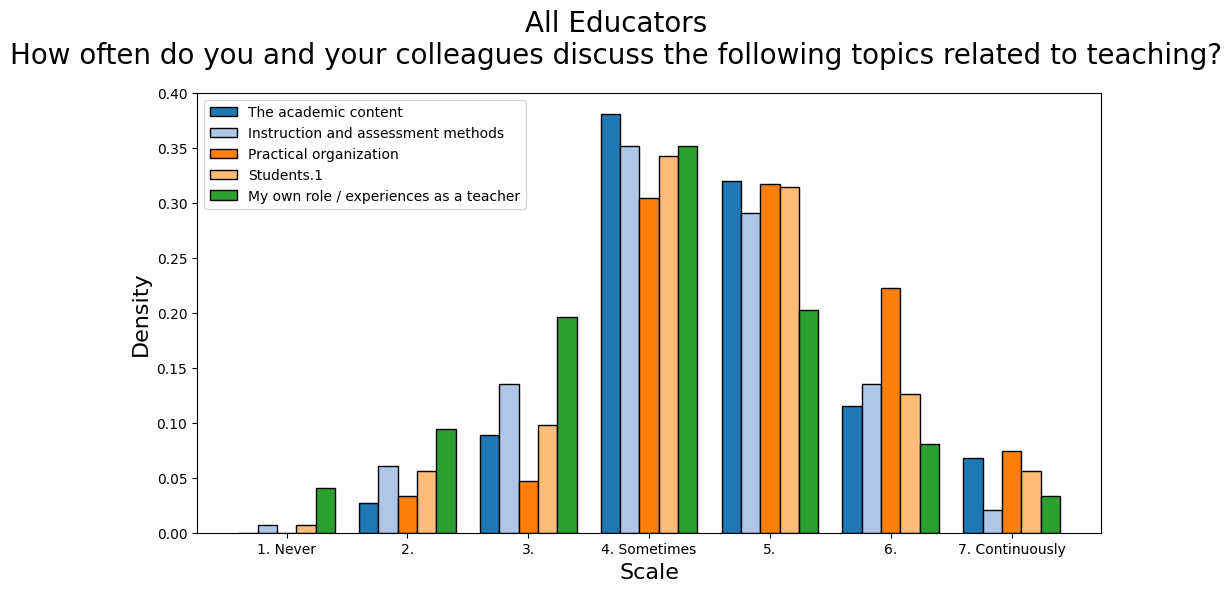

In [5]:
from dataframe_gymnastics import load_loose_educators_data_2019

df_2019_educators, common_questions_educators_2019 = load_loose_educators_data_2019()

survey_2019_educators = Survey()
survey_2019_educators.year = 2019
survey_2019_educators.path = ".."
survey_2019_educators.data = df_2019_educators
survey_2019_educators.get_questions()

questions_to_plot = [
    "Spatial skills (romlig forståelse)",
    "Fieldwork skills",
    "Laboratory skills",
    "Modelling/computing skills",
    "Critical thinking",
    "Theoretical understanding",
    "Collaborative skills",
    "Working in interdisciplinary teams",
    "Scientific writing and reading competence (literacy)",
    "Quantitative competence (ability to interpret data /numeracy)",
    "Communicating scientific/technical content"
]
title = "All Educators\nTo what extent do you believe the following skills\nwill be important for geoscientist in the future?"
make_shared_histogram(questions_to_plot, survey_2019_educators, title, hide=True)

questions_to_plot = [
    "To what extent does the education prepare students for future work in geoscience?",
]
title= "All Educators\nTo what extent does the education at your institution prepare students for their future work in geoscience?"
make_shared_histogram(questions_to_plot, survey_2019_educators, title, hide=True)
questions_to_plot = [
    "To what extent is there coherence (connectedness) between the courses in the study programme?"
]
title = "All Educators\nTo what extent do you think there is coherence (connectedness) between the courses in the study programme?"
make_shared_histogram(questions_to_plot, survey_2019_educators, title, hide=True)


questions_to_plot = [
    "Spatial skills (romlig forståelse).1",
    "Fieldwork skills.1",
    "Laboratory skills.1",
    "Modelling/computing skills.1",
    "Critical thinking.1",
    "Theoretical understanding.1",
    "Collaborative skills.1",
    "Working in interdisciplinary teams.1",
    "Scientific writing and reading competence (literacy).1",
    "Quantitative competence (ability to interpret data /numeracy).1",
    "Communicating scientific/technical content.1"
]
title = "All Educators\nTo what extent do the students acquire these skills\nthrough the geoscience study programme at your institution?"
make_shared_histogram(questions_to_plot, survey_2019_educators, title, hide=True)


questions_to_plot = [
    "The teachers’ have excellent academic competences",
    # "The teachers’ have excellent pedagogical competences", # <- not found in two of the surveys
    "The collegial collaboration in regard to research is excellent",
    "The collegial collaboration in regard to teaching is excellent",
    "The collegial collaboration between academic staff and technical/administration staff is excellent",
    "The general quality of the study programme is excellent"
]
title = "All Educators\nTo what extent do you agree or disagree with the\nfollowing statements about your department?"
make_shared_histogram(questions_to_plot, survey_2019_educators, title, hide=True)


questions_to_plot = [
    "The geoscience department at UiT",
    "The geoscience department at UNIS",
    "The geoscience department at UiO",
    "The geoscience department at UiB",
    "Other departments (not geoscience) at a university",
    "Other geoscience departments at Norwegian universities",
    "Other geoscience departments at non-Norwegian universities",
    "Research institutions"
]
title="All Educators\nTo what extent do you collaborate with persons at the following\ninstitutions in regard to university teaching/development?"
make_shared_histogram(questions_to_plot, survey_2019_educators, title, hide=True)

questions_to_plot = [
    "Academic staff",
    "Students",
    "Administrative/technical staff at the department",
    "Management at the department",
    "IT department",
    "Others"
]
title="All Educators\nHow often do you ask the following people for advice or\nassistance when planning teaching?"
make_shared_histogram(questions_to_plot, survey_2019_educators, title, hide=True)

questions_to_plot = [
    "The academic content",
    "Instruction and assessment methods",
    "Practical organization",
    "Students.1",
    "My own role / experiences as a teacher"
]
title = "All Educators\nHow often do you and your colleagues discuss the following topics related to teaching?"
make_shared_histogram(questions_to_plot, survey_2019_educators, title, hide=False)


In [6]:
intentional error

SyntaxError: invalid syntax (3626927063.py, line 1)

#### 2026

#### All staff

In [ ]:
# use the manually created survey dataset
survey_all_staff_path = r"..\2026data\data_2026_all_staff.xlsx"
survey_all_staff = Survey(survey_all_staff_path)


questions_to_plot = [
    "iEarth influenced your daily work?",
    "iEarth impacted your professional development?",
    "iEarth influenced department policies or procedures around teaching?"
]
title="Alle Ansatte\nOm iEarths innflytelse på arbeid og utvikling"
make_shared_histogram(questions_to_plot, survey_all_staff, title=title)

questions_to_plot = [
    "Fieldwork skills",
    "Laboratory skills",
    "Modelling/computing skills",
    "AI-competence",
    "Quantitative competence (ability to interpret data /numeracy)",
]
title = "Alle Ansatte\nForventede faglige færdigheder"
make_shared_histogram(questions_to_plot, survey_all_staff, title=title)

questions_to_plot = [
    "Collaborating in teams",
]
title = "Alle Ansatte\nForventede samarbejdsevner"
make_shared_histogram(questions_to_plot, survey_all_staff, title=title)

questions_to_plot = [
    "Theoretical understanding"
]
title = "Alle Ansatte\nForventede kognitive ferdigheter"
make_shared_histogram(questions_to_plot, survey_all_staff, title=title)

questions_to_plot = [
    "Communicating scientific/technical content"
]
title = "Alle Ansatte\nForventede formidlingsferdigheter"
make_shared_histogram(questions_to_plot, survey_all_staff, title=title)

questions_to_plot = [
    "The teachers’ have excellent pedagogical competences",
    "The collegial collaboration in regard to research is excellent",
    "The collegial collaboration in regard to teaching is excellent",
    "The collegial collaboration between academic staff and technical/administration staff is excellent",
    "The general quality of the study programme is excellent"
]
title="Alle Ansatte\nOm kvaliteten i studieprogrammet"
make_shared_histogram(questions_to_plot, survey_all_staff, title=title)

questions_to_plot = [
    "To what extent do you think the education at your institution prepare students for their future work in geoscience?"
]
title = "Alle Ansatte\nOm Utdanningens relevans for fremtidig arbeid"
make_shared_histogram(questions_to_plot, survey_all_staff, title=title)



questions_to_plot = [
    "To what extent do you think there is coherence (connectedness) between the courses in the study programme?"
]
title = "Alle Ansatte\nOm Sammenhengen i kursporteføljen"
make_shared_histogram(questions_to_plot, survey_all_staff, title=title)

questions_to_plot = [
    "Fieldwork skills.1",
    "Laboratory skills.1",
    "Modelling/computing skills.1",
    "AI-competence.1",
    "Quantitative competence (ability to interpret data /numeracy).1",
    "Theoretical understanding.1",
    "Collaborating in teams.1",
    "Communicating scientific/technical content.1",
]
title = "Alle Ansatte\nOm de opnåede ferdigheter gennem det nuværende studieprogram"
make_shared_histogram(questions_to_plot, survey_all_staff, title=title)

questions_to_plot = [
    "It is my impression that most students feel comfortable as students at the department",
    "It is my impression that most students feel comfortable as students at the department",
    "It is my impression that the students are good at helping each other",
    "It is my impression there is fierce competition among the students",
    "It is my impression that the students have good possibilities for social contact with their fellow students",
    "It is my impression that the students are highly motivated to study"
]
title = "Alle Ansatte\nOm studentenes trivsel og motivasjon"
make_shared_histogram(questions_to_plot, survey_all_staff, title=title)


questions_to_plot = [
    "Internships make students better prepared for the labour market",
    "Internships give students valuable experiences they cannot get at the university",
    "Internships make geoscience students more motivated",
    "Internships in the study programme comes at the expense of other important learning goals at the university"
]
title = "Alle Ansatte\nOm praktikken i studieprogrammet"
make_shared_histogram(questions_to_plot, survey_all_staff, title=title)


questions_to_plot = [
    "Practical skills in specific professional fields (analytical procedures and equipment)",
    "Understanding of applied methods",
    "Enabling the understanding and value of their education in the labor market",
    "Knowledge and understanding the practical application of theory",
    "Communication, written and oral",
    "Collaborative skills"
]
title= "Alle Ansatte\nOm de opnående ferdigheter for gennem praktik"
make_shared_histogram(questions_to_plot, survey_all_staff, title=title)


C:\Users\NoahH\AppData\Local\Temp\ipykernel_7160\1279765046.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_questions)
C:\Users\NoahH\AppData\Local\Temp\ipykernel_7160\1279765046.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_questions)
C:\Users\NoahH\AppData\Local\Temp\ipykernel_7160\1279765046.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab

question_text = 'Enabling the understanding and value of their education in the labor market'
question_text = 'Communication, written and oral'


#### Educators

In [ ]:
survey_educators_path = r"..\2026data\data_2026_educators.xlsx"
survey_educators = Survey(survey_educators_path)

questions_to_plot = [
    "My colleagues are open for new ideas with regards to teaching",
    "My colleagues support me when I want to develop my teaching",
    "My colleagues understand the problems I experience with regards to teaching",
    "I do not discuss my teaching with colleagues",
    "I am confident in my abilities as a teacher",
    "I like to teach"
]
title = "Alle Undervisere\nOm det at være underviser"
make_shared_histogram(questions_to_plot, survey_educators, title=title)


questions_to_plot = [
    "Written evaluations from students (course evaluations)",
    "Informal feed-back from students",
    "Guidance conversation with university educational expert",
    "That a colleague is present while you teach and afterwards gives you feedback (peer feedback)"
]
title = "Alle Undervisere\nRelevansen av ulike former for feedback"
make_shared_histogram(questions_to_plot, survey_educators, title=title)


questions_to_plot = [
    "It is my impression that most students feel comfortable as students at the department",
    "It is my impression that most students feel comfortable as students at the department",
    "It is my impression that the students are good at helping each other",
    "It is my impression there is fierce competition among the students",
    "It is my impression that the students have good possibilities for social contact with their fellow students",
    "It is my impression that the students are highly motivated to study"
]
title = "Alle Undervisere\nUndervisernes opplevelse av studentenes læringsmiljø"
make_shared_histogram(questions_to_plot, survey_educators, title=title)

questions_to_plot = [
    "Fieldwork skills.1",
    "Laboratory skills.1",
    "Modelling/computing skills.1",
    "AI-competence.1",
    "Quantitative competence (ability to interpret data /numeracy).1",
    "Theoretical understanding.1",
    "Collaborating in teams.1",
    "Communicating scientific/technical content.1"
]
title="Alle Undervisere\nFerdigheter du opplever at studentene lærer i kurset du underviser"
make_shared_histogram(questions_to_plot, survey_educators, title=title)

questions_to_plot = [
    "Practical skills in specific professional fields (analytical procedures and equipment)",
    "Understanding of the subject methods",
    "Understanding of data collection and uncertainties",
    "Understanding of the subject theory",
    "Knowledge and understanding of processes in nature",
    "Formulating/testing hypotheses",
    "Collaborative skills.1" # <- there is one earlier
]
title = "Alle Undervisere\nVurderte tekniske ferdigheter oppnådd gjennom feltarbeid"
make_shared_histogram(questions_to_plot, survey_educators, title=title)


questions_to_plot = [
    "Internships make students better prepared for the labour market",
    "Internships give students valuable experiences they cannot get at the university",
    "Internships make geoscience students more motivated",
    "Internships in the study programme comes at the expense of other important learning goals at the university"
]
title= "Alle Undervisere\nUndervisernes opplevelse av internship for studentene"
make_shared_histogram(questions_to_plot, survey_educators, title=title)

questions_to_plot = [
    "Internships give students valuable experiences they cannot get at the university",
    "Internships make geoscience students more motivated",
    "Internships in the study programme comes at the expense of other important learning goals at the university",
    "Practical skills in specific professional fields (analytical procedures and equipment)",
    "Understanding of applied methods",
    "Enabling the understanding and value of their education in the labor market.",
    "Knowledge and understanding the practical application of theory",
    "Communication, written and oral.",
    "Collaborative skills"
]
title = "Alle Undervisere\nUndervisernes opplevelse av udbytte af internships for studentene"
make_shared_histogram(questions_to_plot, survey_educators, title=title)


C:\Users\NoahH\AppData\Local\Temp\ipykernel_7160\1279765046.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_questions)
C:\Users\NoahH\AppData\Local\Temp\ipykernel_7160\1279765046.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_questions)
C:\Users\NoahH\AppData\Local\Temp\ipykernel_7160\1279765046.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab

#### Students

In [ ]:
survey_students_path = r"..\2026data\data_2026_students.xlsx"
survey_students = Survey(survey_students_path)

questions_to_plot = [
    "Be engaging",
    "Be academically challenging",
    "Consist of courses that integrate well",
    "Have skilled teachers"
]
title = "Alle Studerende\nSyn på utdanningen"
make_shared_histogram(questions_to_plot, survey_students, title=title)


# not well defined axis. Could be made as a special case
# questions_to_plot = [
#     "How well do you know iEarth?.I have been involved as a student partner",
#     "How well do you know iEarth?.I know what it is",
#     "How well do you know iEarth?.I have an idea about what is",
#     "How well do you know iEarth?.I have heard someone mention it, but I am not sure",
#     "How well do you know iEarth?.I have no idea / never heard of it"
# ]
# title = "Alle Studerende\nKjennskap til iEarth"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "National courses (GeoPraksis/RealfagsPraksis, Geofare Kurs)",
    "GeoLearning conferences",
    "GeOrakel student activity",
    "Career day",
    "Student assistant in courses"
]
title = "Alle Studerende\nDeltagelse i aktiviteter. Wrong scale, ambigous use of work 'never'"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "The geoscience department at UiT",
    "The geoscience department at UNIS",
    "The geoscience department at UiO",
    "The geoscience department at UiB",
    "The geophysical department at UiB",
    "Other departments (not geoscience) at a university",
    "Other geoscience departments at Norwegian universities",
    "Other geoscience departments at non-Norwegian universities (international)",
    "Research institutions"
]
title = "Alle Studerende\nSamarbejde med institusjoner"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "Fieldwork skills",
    "Laboratory skills",
    "Modelling/computing skills",
    "AI-competence",
    "Quantitative competence (ability to interpret data /numeracy)",
]
title = "Alle Studerende\nForventede faglige færdigheder"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "Collaborating in teams",
]
title = "Alle Studerende\nForventede samarbejdsevner"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "Theoretical understanding"
]
title = "Alle Studerende\nForventede kognitive ferdigheter"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "Communicating scientific/technical content"
]
title = "Alle Studerende\nForventede formidlingsferdigheter"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "To what extent do you think the education at your institution prepare you as students for  future work in geoscience?",
    "To what extent do you think there is coherence (connectedness) between the courses in the study program?"
]
title = "Alle Studerende\nOm Utdanningens relevans for fremtidig arbeid og sammenhengen i kursporteføljen"
make_shared_histogram(questions_to_plot, survey_students, title=title)

# In previous article the difference between expected and experienced were presented. We run into a problem here, 
# since the "expected" and "archieved" are not on the same scale in the 2026 data
questions_to_plot = [
    "Fieldwork skills.1",
    "Laboratory skills.1",
    "Modelling/computing skills.1",
    "AI-competence.1",
    "Quantitative competence (ability to interpret data /numeracy).1",
]
title = "Alle Studerende\nOplevede faglige færdigheder"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "Collaborating in teams.1",
]
title = "Alle Studerende\nOplevede samarbejdsevner"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "Theoretical understanding.1"
]
title = "Alle Studerende\nOplevede kognitive ferdigheter"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "Communicating scientific/technical content.1"
]
title = "Alle Studerende\nOplevede formidlingsferdigheter"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "Teachers are available when I contact them",
    "The teachers that I have been in contact with generally seem interested in the students",
    "I feel understood by my teachers",
    "My teachers conveys confidence in my ability to do well in the courses",
    "My teachers encourage me to ask questions",
    "My teachers listen to how I like to do things",
    "My teachers try to understand how I see things before suggesting a new way to do things"
]
title = "Alle Studerende\nOplevese af lærere"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "The academic content",
    "Instruction and exams",
    "Practical organization of courses",
    "My own role / attitudes as a students",
    "Teacher’s pedagogical approaches to teaching"
]
title = "Alle Studerende\nOplevese af kurser"
make_shared_histogram(questions_to_plot, survey_students, title=title)

# questions_to_plot = [
#     "Lecture with black/whiteboard",	
#     "Lecture with PowerPoint",	
#     "Practical exercises","Seminars",
#     "Student presentations in class",
#     "Group work",
#     "Self-study (reading or doing exercises by myself)"
# ]
# title = "Alle Studerende\nOplevese af undervisningsformer"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "How satisfied are you with the study environment?"
]
title = "Alle Studerende\nOplevese af læringsmiljø"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "Most students feel comfortable as students at the department",
    "The students are generally satisfied with their studies",
    "The students are good at helping each other",
    "There is fierce competition among the students",
    "The students have good possibilities for social contact with their fellow students",
    "That the students are highly motivated to study"
]
title = "Alle Studerende\nOplevese af studentenes læringsmiljø"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "I am confident in my abilities to learn geoscience",
    "I am capable of learning what is expected",
    "I am able to achieve my goals",
    "I am able to meet challenges and perform well"
]
title = "Alle Studerende\nOplevese af egne evner"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "I feel comfortable as a student here",
    "I am satisfied with my studies",
    "I can receive help and support from my fellow students when I need it",
    "Academically, I get a lot out of talking to other students",
    "I find that competition among students is fierce",
    "The possibilities for social contact with my fellow students are good"
]
title = "Alle Studerende\nDen studerendes egen oplevelse af læringsmiljø"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "Have you experienced feeling lonely in connection with your daily studies?",
    "Have you experienced strong stress-related symptoms* in connection with your daily studies?",
    "Have you experienced strong stress symptoms * in your study up to the exam?"
]
title = "Alle Studerende\nOplevese af ensomhed og stress"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "I often consider dropping out of my courses",
    "I am confident that I will continue my studies",
    "I have often considered quitting my studies",
    "Sometimes I think about leaving the study programme",
    "I have decided to leave the study programme"
]
title = "Alle Studerende\nOplevese af frafaldstanker"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "The teachers spend time discussing with us what characterises a good assignment",
    "The possibilities for receiving feedback regarding my academic performance at exams are good (in addition to grades)",
    "It is very difficult to know whether I’m doing well throughout the semester",
    "I am confident that I am learning what is required",
    "When I get feedback on my academic work, it is easy for me to know how to improve"
]
title = "Alle Studerende\nOplevese af feedback"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "Grades",
    "Individual written feedback on assignments (few sentences) from teacher / teaching assistant",
    "Individual feedback from other students",
    "General feedback to the student group from the teacher",
    "Conversations with teacher",
    "Conversations with teaching assistants"
]
title = "Alle Studerende\nOplevese af feedbackformer"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "Oral feedback to teachers",
    "Survey based feedback/evaluation",
    "Informal feedback to Teaching assistants."
]
title = "Alle Studerende\nHvor ofte de giver feedback"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "Practical skills in specific professional fields (analytical procedures and equipment)",
    "Understanding of data collection and uncertainties",
    "Connecting theory and practice",
    "Knowledge and understanding of processes in nature",
    "Formulating/testing hypotheses",
    "Collaborative skills"
]
title = "Alle Studerende\nVurderte tekniske ferdigheter oppnådd gjennom feltarbeid"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "Internships make students better prepared for the labour market",
    "Internships give students valuable experiences they cannot get at the university",
    "Internships make geoscience students more motivated",
    "Internships in the study programme comes at the expense of other important learning goals at the university"
]
title = "Alle Studerende\nUndervisernes opplevelse av internship for studentene"
make_shared_histogram(questions_to_plot, survey_students, title=title)

questions_to_plot = [
    "Practical skills in specific professional fields",
    "Connecting theory and practice.1",
    "Enabling the understanding and value of their education in the labor market",
    "Communication, written and oral",
    "Collaborative skills.1"
]
title = "Alle Studerende\nUndervisernes opplevelse av udbytte af internships for studentene"
make_shared_histogram(questions_to_plot, survey_students, title=title)



self.path = '..\\2026data\\data_2026_students.xlsx'
HERE
question.raw_text = 'How satisfied are you with the study environment?'


C:\Users\NoahH\AppData\Local\Temp\ipykernel_7160\1279765046.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_questions)
C:\Users\NoahH\AppData\Local\Temp\ipykernel_7160\1279765046.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_questions)
C:\Users\NoahH\AppData\Local\Temp\ipykernel_7160\1279765046.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab

question_text = 'AI-competence.1'


C:\Users\NoahH\AppData\Local\Temp\ipykernel_7160\1279765046.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_questions)
C:\Users\NoahH\AppData\Local\Temp\ipykernel_7160\1279765046.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_questions)
C:\Users\NoahH\AppData\Local\Temp\ipykernel_7160\1279765046.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab

question_text = 'Enabling the understanding and value of their education in the labor market'
question_text = 'Communication, written and oral'
